In [1]:
import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run


run = open_run("20260924201902")
run.info()

Run_ID,Sim_Type,Status,Directory,Trajectory,HDF5,Frame_Count
20260924201902,Expanded_FCC,Complete,/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260924201902,/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260924201902/trajectory.gsd,/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260924201902/run.hdf5,151


Run_ID,Run_Signature,N_Cells,Nsteps,Current_Nstep,ElapsedTime,StartTime,EndTime,Last_Update_Time,Sim_Type,Status,Stop_Reason,Status_Message,Notes
20260924201902,4f32dbadb07df43b132b6bfdd7a1fd6e4115e1e0e9cca61099046fbdd1d28c71,30,1500000,1500000,4151.403203,2026-09-24 20:19:03.118840,2026-09-24 21:31:57.651475,2026-09-24 21:31:57.651475,Expanded_FCC,Complete,None,None,Expanded FCC: center length 3L; 2 original box length(s) added per side; side density divided by 25.


{'Run_ID': '20260924201902',
 'Sim_Type': 'Expanded_FCC',
 'Status': 'Complete',
 'Directory': '/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260924201902',
 'Trajectory': '/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260924201902/trajectory.gsd',
 'HDF5': '/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260924201902/run.hdf5',
 'Frame_Count': 151}

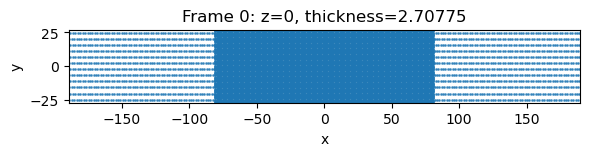

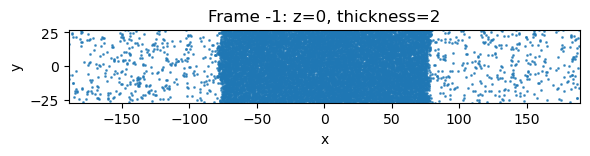

In [2]:
# 3D views
#run.render(frame=0)
#run.render(frame=-1)
#run.render_movie()

# XY slices
run.xy_slice(frame=0)
run.xy_slice(frame=-1, z=0, thickness=2.0);
#run.xy_slice(frames=[0, 10, 20, -1])
run.xy_slice_movie(frame_step=1);

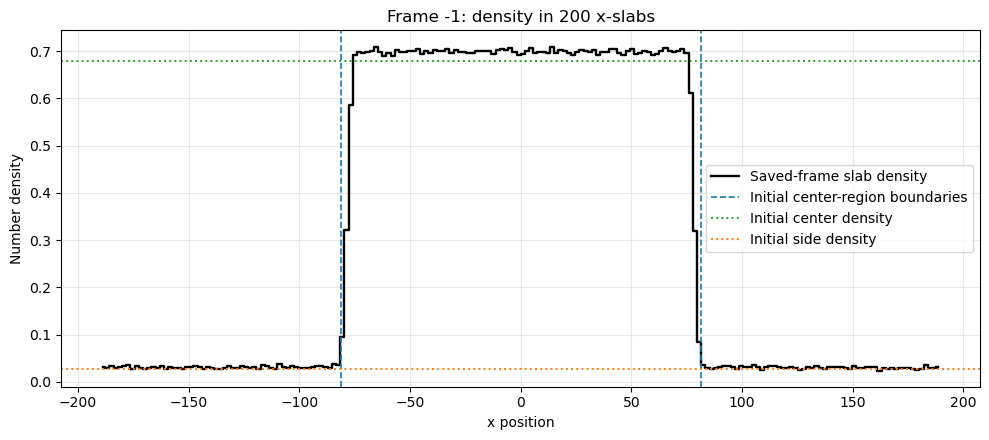

In [3]:
figure, density_slices = run.plot_density_profile(
    frame=-1,
    num_slices=200,
)

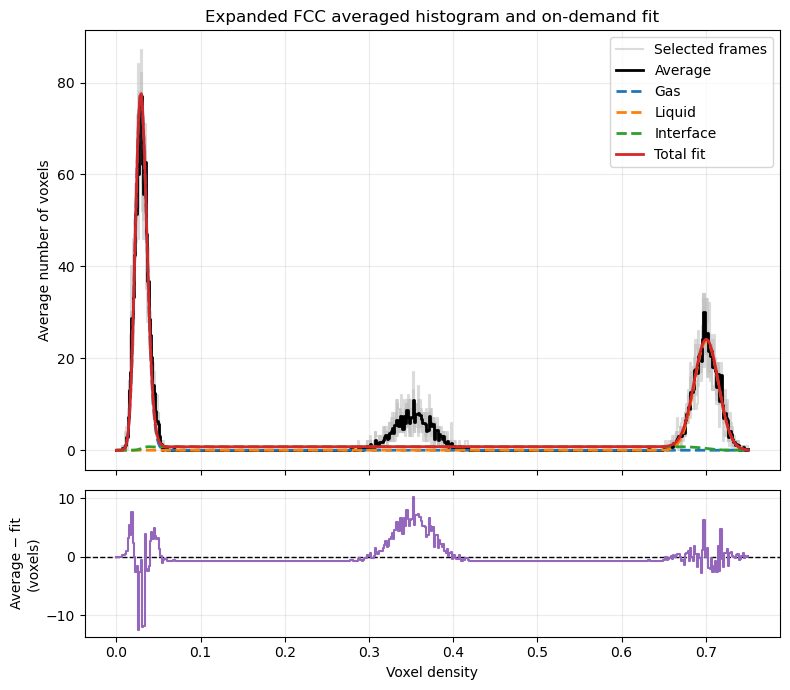

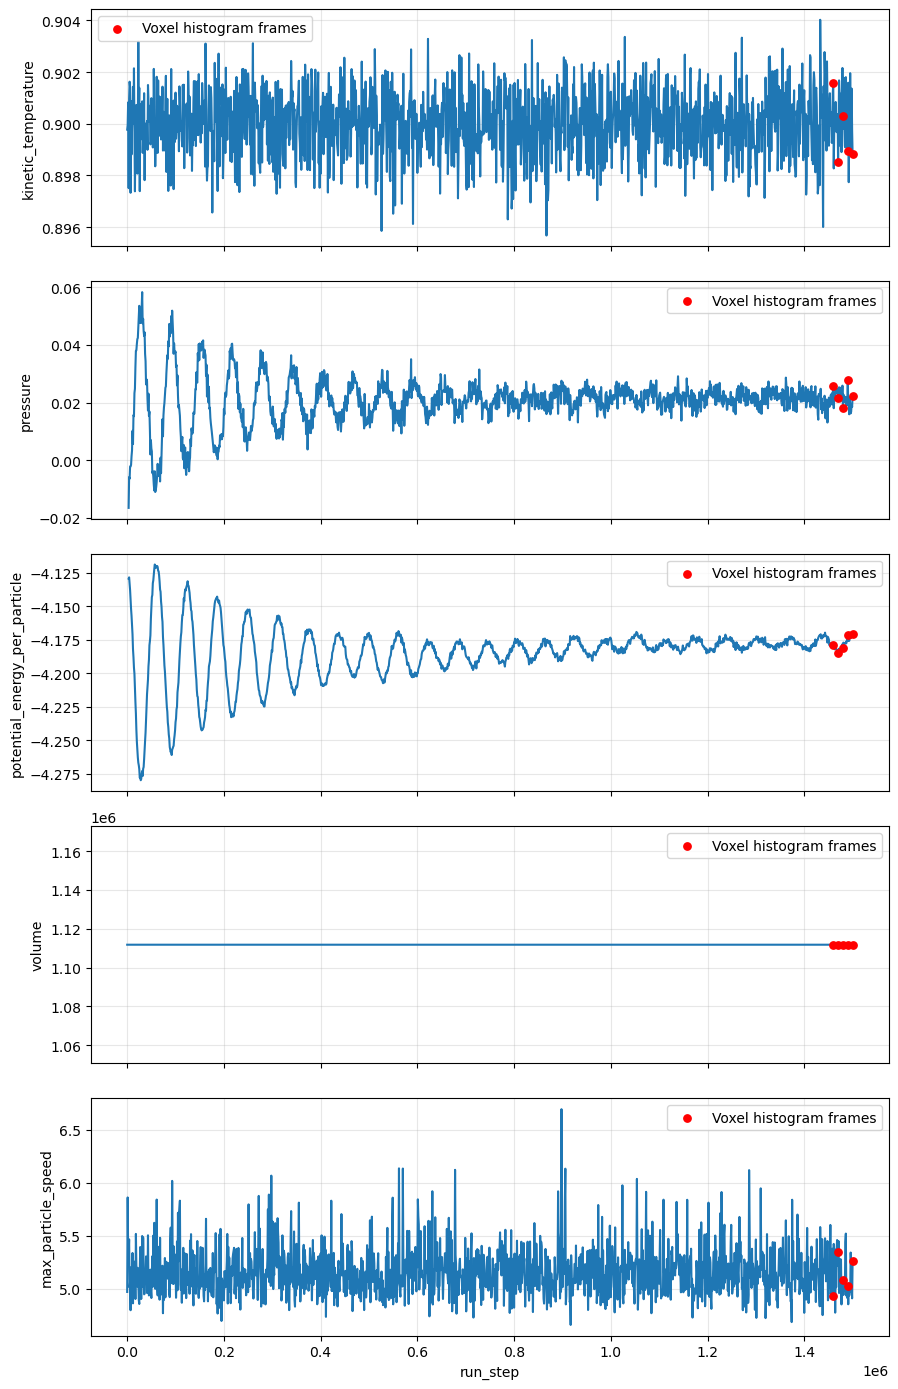

In [4]:
# Phase fit and logs
run.plot_phase_fit();
run.plot_logs();

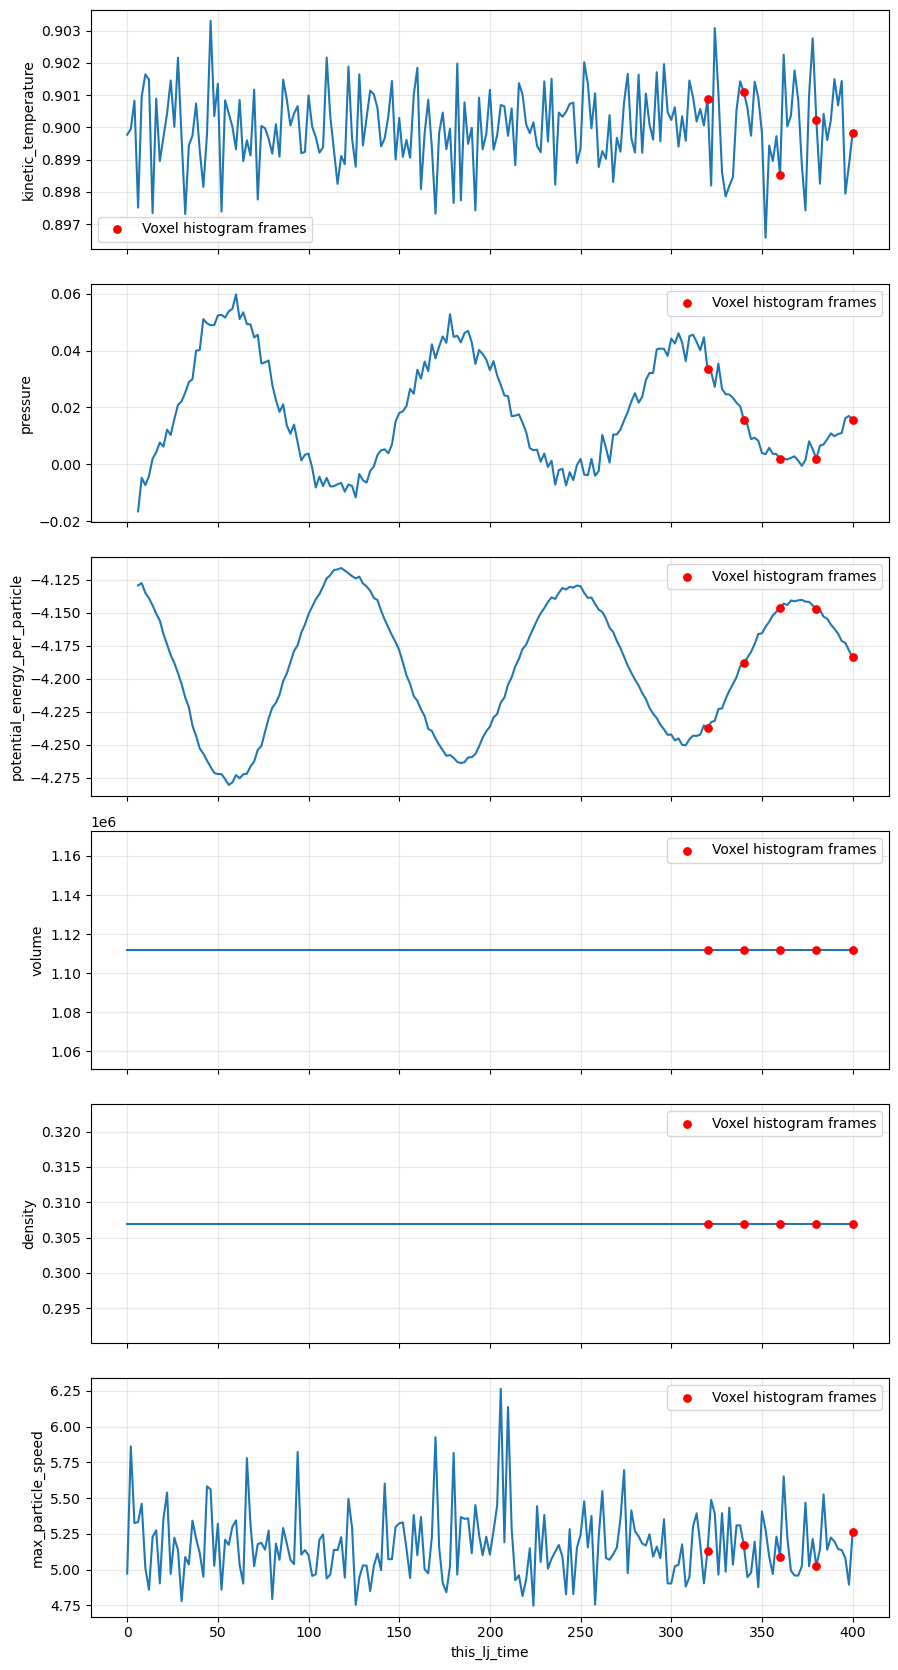

In [8]:
run.plot_logs(
    [
        "kinetic_temperature",
        "pressure",
        "potential_energy_per_particle",
        "volume",
        "density",
        "max_particle_speed",
    ],
    x="this_lj_time",
);

#x="frame"
#x="hoomd_timestep"
#x="run_step"
#x="this_lj_time"
#x="cumulative_lj_time"

In [25]:
"""logs = run.logs_dataframe()
metadata = run.metadata()
frame_table = run.frame_table()

for field, value in metadata.items():
    print(f"{field}: {value}")
    """

'logs = run.logs_dataframe()\nmetadata = run.metadata()\nframe_table = run.frame_table()\n\nfor field, value in metadata.items():\n    print(f"{field}: {value}")\n    '

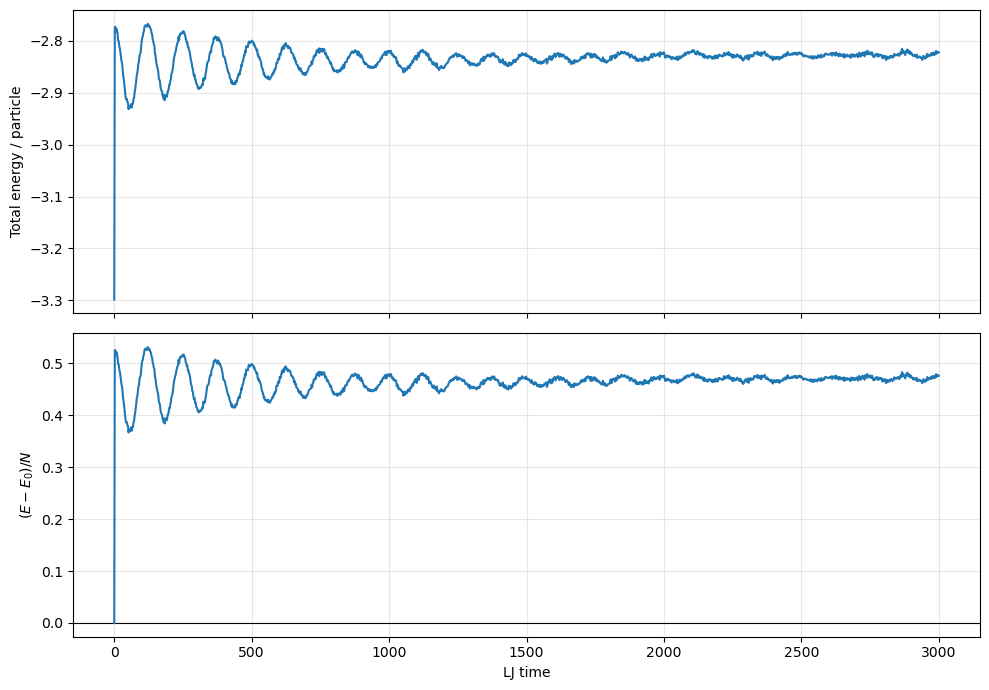

In [5]:
import matplotlib.pyplot as plt

logs = run.logs_dataframe()

logs["total_energy"] = (
    logs["kinetic_energy"]
    + logs["potential_energy"]
)

logs["total_energy_per_particle"] = (
    logs["total_energy"]
    / logs["num_particles"]
)

initial_energy = logs["total_energy_per_particle"].iloc[0]

logs["energy_change_per_particle"] = (
    logs["total_energy_per_particle"]
    - initial_energy
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    logs["this_lj_time"],
    logs["total_energy_per_particle"],
)

axes[0].set_ylabel("Total energy / particle")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].plot(
    logs["this_lj_time"],
    logs["energy_change_per_particle"],
)

axes[1].set_xlabel("LJ time")
axes[1].set_ylabel(r"$(E-E_0)/N$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

,parameter,value
0,E_inf,-3.957829
1,A,0.089189
2,tau_osc,576.260563
3,period,125.171414
4,phase,0.448094
5,B,-0.235041
6,tau_slow,39773.431735
7,R_squared,0.968144


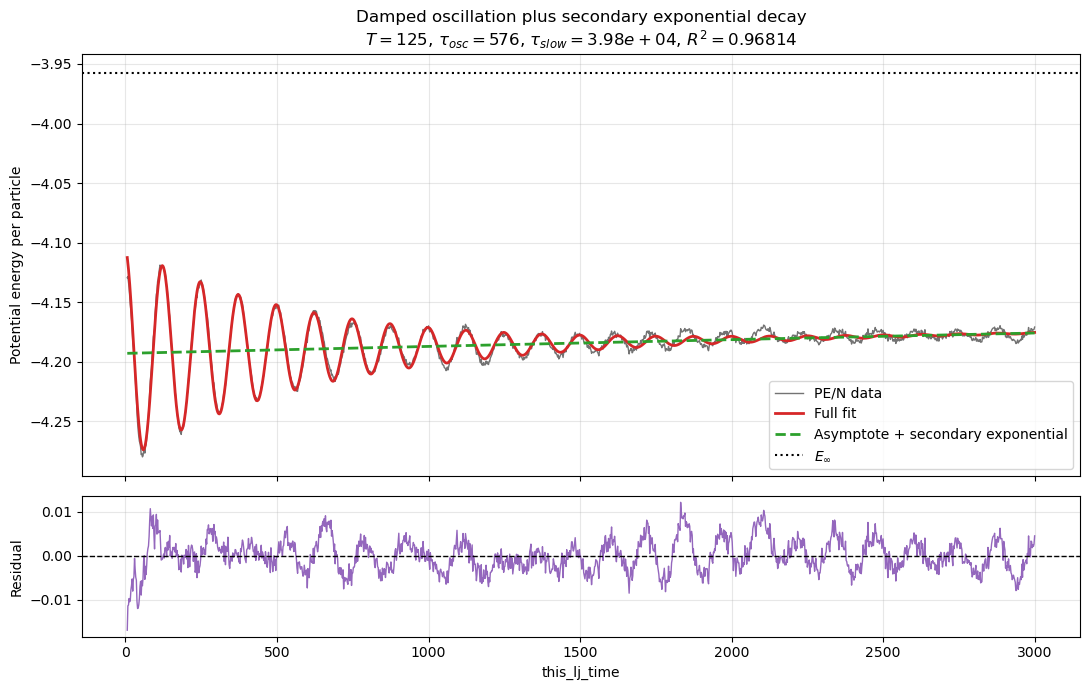

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.signal import detrend

# Load PE/N and skip the first three transient points.
logs = (
    run.logs_dataframe()
    .sort_values("this_lj_time")
    .reset_index(drop=True)
)

fit_data = logs.iloc[3:].copy()
x = fit_data["this_lj_time"].to_numpy(dtype=float)
y = fit_data["potential_energy_per_particle"].to_numpy(dtype=float)

finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]

# Shift time to improve numerical conditioning.
x0 = x[0]
t = x - x0
span = t[-1] - t[0]
dt = np.median(np.diff(t))

def pe_model(t, E_inf, A, tau_osc, period, phase, B, tau_slow):
    oscillation = (
        A
        * np.exp(-t / tau_osc)
        * np.cos(2.0 * np.pi * t / period + phase)
    )
    slow_decay = B * np.exp(-t / tau_slow)
    return E_inf + oscillation + slow_decay

# Estimate the dominant oscillation period with an FFT.
frequencies = np.fft.rfftfreq(len(t), d=dt)
spectrum = np.abs(np.fft.rfft(detrend(y)))

valid_frequency = (
    (frequencies > 1.0 / span)
    & (frequencies < 0.5 / dt)
)
peak_index = np.flatnonzero(valid_frequency)[
    np.argmax(spectrum[valid_frequency])
]
period0 = 1.0 / frequencies[peak_index]

tail_count = max(10, len(y) // 5)
E_inf0 = np.median(y[-tail_count:])
data_range = np.ptp(y)

early_count = max(5, len(y) // 20)
A0 = max(
    np.max(np.abs(y[:early_count] - E_inf0)),
    0.25 * data_range,
)
B0 = np.mean(y[:early_count]) - E_inf0

p0 = np.array([
    E_inf0,               # Long-time PE/N
    A0,                   # Initial oscillation amplitude
    max(span / 3, dt),    # Oscillation decay time
    period0,              # Oscillation period
    0.0,                  # Phase
    B0,                   # Secondary exponential amplitude
    max(span / 2, dt),    # Secondary decay time
])

period_lower = max(2.1 * dt, period0 / 4)
period_upper = min(span, 4 * period0)

lower = np.array([
    y.min() - data_range,
    0.0,
    dt,
    period_lower,
    -2 * np.pi,
    -2 * data_range,
    dt,
])

upper = np.array([
    y.max() + data_range,
    3 * data_range,
    100 * span,
    period_upper,
    2 * np.pi,
    2 * data_range,
    100 * span,
])

# Robust fitting reduces the influence of isolated noisy samples.
tail = y[-tail_count:]
noise_scale = 1.4826 * np.median(np.abs(tail - np.median(tail)))
noise_scale = max(noise_scale, 1e-6)

fit = least_squares(
    lambda parameters: pe_model(t, *parameters) - y,
    x0=p0,
    bounds=(lower, upper),
    loss="soft_l1",
    f_scale=noise_scale,
    x_scale="jac",
    max_nfev=100_000,
)

parameter_names = [
    "E_inf",
    "A",
    "tau_osc",
    "period",
    "phase",
    "B",
    "tau_slow",
]
parameters = dict(zip(parameter_names, fit.x))

y_fit = pe_model(t, *fit.x)
E_inf, A, tau_osc, period, phase, B, tau_slow = fit.x

slow_component = E_inf + B * np.exp(-t / tau_slow)
oscillatory_component = (
    A
    * np.exp(-t / tau_osc)
    * np.cos(2 * np.pi * t / period + phase)
)
residual = y - y_fit

ss_residual = np.sum(residual**2)
ss_total = np.sum((y - np.mean(y))**2)
r_squared = 1.0 - ss_residual / ss_total

display(pd.DataFrame({
    "parameter": parameter_names + ["R_squared"],
    "value": list(fit.x) + [r_squared],
}))

figure, (axis, residual_axis) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axis.plot(x, y, color="0.45", linewidth=1, label="PE/N data")
axis.plot(x, y_fit, color="tab:red", linewidth=2, label="Full fit")
axis.plot(
    x,
    slow_component,
    color="tab:green",
    linestyle="--",
    linewidth=2,
    label="Asymptote + secondary exponential",
)
axis.axhline(
    E_inf,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=r"$E_\infty$",
)
axis.set_ylabel("Potential energy per particle")
axis.set_title(
    "Damped oscillation plus secondary exponential decay\n"
    rf"$T={period:.3g}$, "
    rf"$\tau_{{osc}}={tau_osc:.3g}$, "
    rf"$\tau_{{slow}}={tau_slow:.3g}$, "
    rf"$R^2={r_squared:.5f}$"
)
axis.grid(alpha=0.3)
axis.legend()

residual_axis.plot(x, residual, color="tab:purple", linewidth=1)
residual_axis.axhline(0, color="black", linestyle="--", linewidth=1)
residual_axis.set_xlabel("this_lj_time")
residual_axis.set_ylabel("Residual")
residual_axis.grid(alpha=0.3)

figure.tight_layout()
plt.show()

,parameter,value
0,C0,-4.192562
1,D,0.321965
2,tau_slow,55881.282464
3,A1,0.030531
4,tau1,1273.950166
5,period1,124.533303
6,phase1,0.654273
7,A2,0.060984
8,tau2,453.907614
9,period2,128.458659


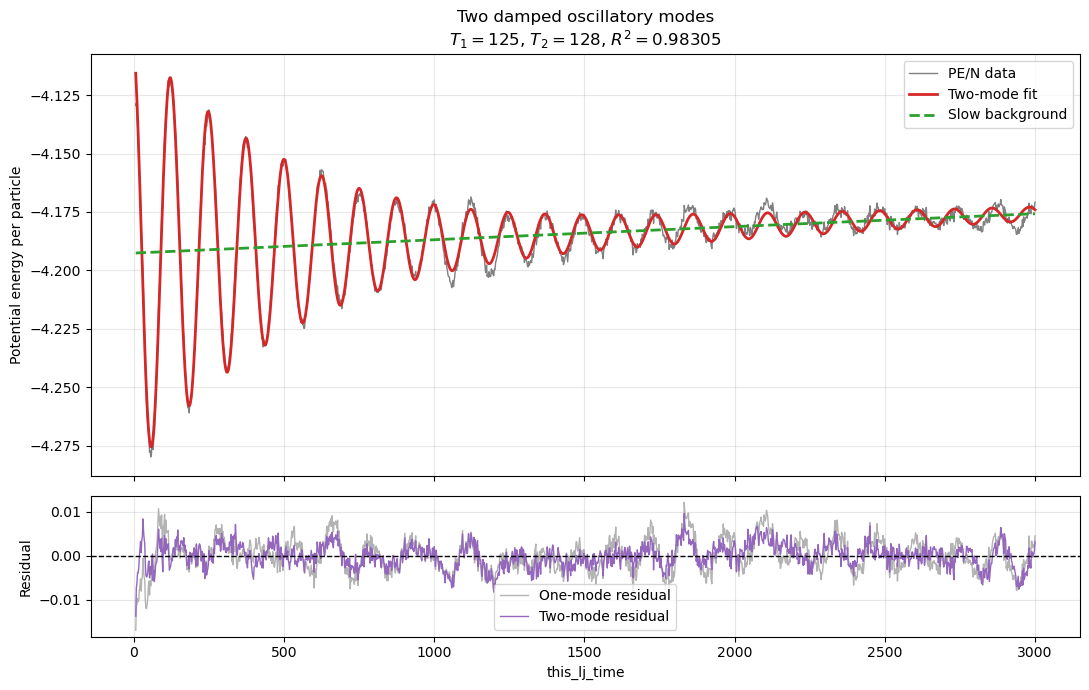

In [7]:
# Two-mode damped-oscillation fit
# Uses x, t, y, fit, pe_model, span, dt, data_range, and noise_scale
# from the previous cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.signal import detrend

# Find the strongest frequency left in the first-fit residual.
old_parameters = fit.x
old_prediction = pe_model(t, *old_parameters)
old_residual = y - old_prediction

frequencies = np.fft.rfftfreq(len(t), d=dt)
residual_spectrum = np.abs(np.fft.rfft(detrend(old_residual)))

valid = (
    (frequencies > 1.0 / span)
    & (frequencies < 0.5 / dt)
)

second_peak = np.flatnonzero(valid)[
    np.argmax(residual_spectrum[valid])
]
period2_initial = 1.0 / frequencies[second_peak]

def two_mode_model(
    t,
    C0,
    D,
    tau_slow,
    A1,
    tau1,
    period1,
    phase1,
    A2,
    tau2,
    period2,
    phase2,
):
    slow_background = C0 + D * (1.0 - np.exp(-t / tau_slow))

    mode1 = (
        A1
        * np.exp(-t / tau1)
        * np.cos(2.0 * np.pi * t / period1 + phase1)
    )

    mode2 = (
        A2
        * np.exp(-t / tau2)
        * np.cos(2.0 * np.pi * t / period2 + phase2)
    )

    return slow_background + mode1 + mode2

E_inf, A1, tau1, period1, phase1, B, tau_slow = old_parameters

# Convert the previous E_inf + B exp(-t/tau) representation:
# C0 is the slow background at t=0 and D is its eventual change.
C0_initial = E_inf + B
D_initial = -B

A2_initial = max(
    np.sqrt(2.0) * np.std(old_residual),
    0.01 * data_range,
)

p0 = np.array([
    C0_initial,
    D_initial,
    tau_slow,
    A1,
    tau1,
    period1,
    phase1,
    A2_initial,
    max(span, dt),
    period2_initial,
    0.0,
])

minimum_period = 2.1 * dt
maximum_period = span

lower = np.array([
    y.min() - data_range,  # C0
    -2 * data_range,       # D
    dt,                    # tau_slow
    0.0,                   # A1
    dt,                    # tau1
    minimum_period,        # period1
    -2 * np.pi,            # phase1
    0.0,                   # A2
    dt,                    # tau2
    minimum_period,        # period2
    -2 * np.pi,            # phase2
])

upper = np.array([
    y.max() + data_range,
    2 * data_range,
    100 * span,
    3 * data_range,
    100 * span,
    maximum_period,
    2 * np.pi,
    3 * data_range,
    100 * span,
    maximum_period,
    2 * np.pi,
])

two_mode_fit = least_squares(
    lambda parameters: two_mode_model(t, *parameters) - y,
    x0=np.clip(p0, lower + 1e-12, upper - 1e-12),
    bounds=(lower, upper),
    loss="soft_l1",
    f_scale=noise_scale,
    x_scale="jac",
    max_nfev=200_000,
)

names = [
    "C0",
    "D",
    "tau_slow",
    "A1",
    "tau1",
    "period1",
    "phase1",
    "A2",
    "tau2",
    "period2",
    "phase2",
]

parameters = dict(zip(names, two_mode_fit.x))
y_two_mode = two_mode_model(t, *two_mode_fit.x)
new_residual = y - y_two_mode

# Compare models while penalizing the four additional parameters.
rss_one = np.sum(old_residual**2)
rss_two = np.sum(new_residual**2)
n = len(y)
k_one = 7
k_two = 11

aic_one = n * np.log(rss_one / n) + 2 * k_one
aic_two = n * np.log(rss_two / n) + 2 * k_two
bic_one = n * np.log(rss_one / n) + k_one * np.log(n)
bic_two = n * np.log(rss_two / n) + k_two * np.log(n)

r_squared = 1.0 - rss_two / np.sum((y - np.mean(y))**2)

results = pd.DataFrame({
    "parameter": names + [
        "R_squared",
        "AIC_two_mode",
        "BIC_two_mode",
        "delta_AIC_vs_one_mode",
        "delta_BIC_vs_one_mode",
    ],
    "value": list(two_mode_fit.x) + [
        r_squared,
        aic_two,
        bic_two,
        aic_two - aic_one,
        bic_two - bic_one,
    ],
})
display(results)

C0, D, tau_slow = two_mode_fit.x[:3]
slow_background = C0 + D * (1.0 - np.exp(-t / tau_slow))

figure, (axis, residual_axis) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axis.plot(x, y, color="0.5", linewidth=1, label="PE/N data")
axis.plot(x, y_two_mode, color="tab:red", linewidth=2, label="Two-mode fit")
axis.plot(
    x,
    slow_background,
    color="tab:green",
    linestyle="--",
    linewidth=2,
    label="Slow background",
)
axis.set_ylabel("Potential energy per particle")
axis.set_title(
    "Two damped oscillatory modes\n"
    rf"$T_1={parameters['period1']:.3g}$, "
    rf"$T_2={parameters['period2']:.3g}$, "
    rf"$R^2={r_squared:.5f}$"
)
axis.grid(alpha=0.3)
axis.legend()

residual_axis.plot(
    x,
    old_residual,
    color="0.7",
    linewidth=1,
    label="One-mode residual",
)
residual_axis.plot(
    x,
    new_residual,
    color="tab:purple",
    linewidth=1,
    label="Two-mode residual",
)
residual_axis.axhline(0, color="black", linestyle="--", linewidth=1)
residual_axis.set_xlabel("this_lj_time")
residual_axis.set_ylabel("Residual")
residual_axis.grid(alpha=0.3)
residual_axis.legend()

figure.tight_layout()
plt.show()

,quantity,value
0,initial_period,126.879716
1,final_period,119.282791
2,alpha,0.000001
3,tau_amplitude,587.730405
4,tau_slow,55672.715355
5,delta_AIC_vs_fixed,-557.840841
6,delta_BIC_vs_fixed,-552.528955


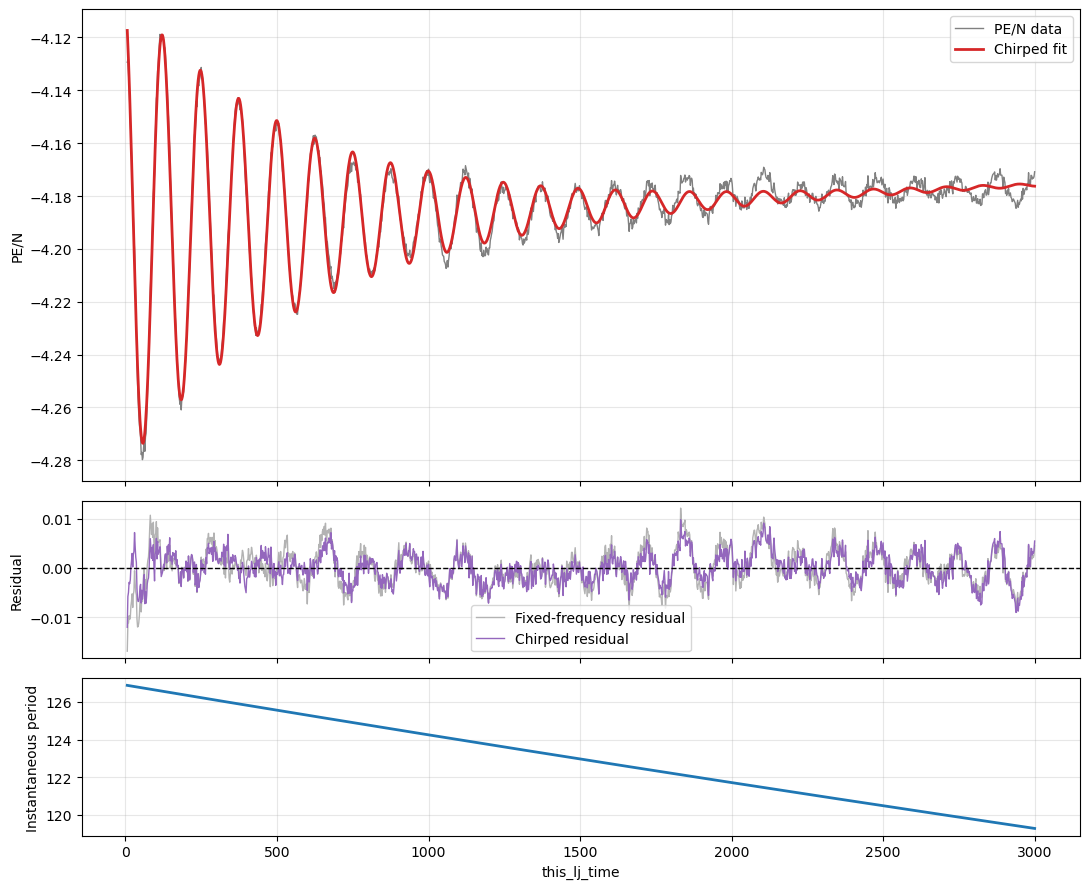

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

# Uses x, t, y, fit, pe_model, span, dt, data_range, and noise_scale
# from the original fitting cell.

old_parameters = fit.x
old_prediction = pe_model(t, *old_parameters)
old_residual = y - old_prediction

E_inf, A, tau_amp, period0, phase, B, tau_slow = old_parameters

def chirped_model(
    t,
    C0,
    D,
    tau_slow,
    A,
    tau_amp,
    omega0,
    alpha,
    phase,
):
    slow_background = C0 + D * (1.0 - np.exp(-t / tau_slow))
    instantaneous_phase = (
        phase
        + omega0 * t
        + 0.5 * alpha * t**2
    )
    oscillation = (
        A
        * np.exp(-t / tau_amp)
        * np.cos(instantaneous_phase)
    )
    return slow_background + oscillation

omega0_initial = 2.0 * np.pi / period0

# Permit the frequency to change by several tens of percent over the run.
alpha_scale = 0.75 * omega0_initial / span

p0 = np.array([
    E_inf + B,       # C0: slow background at t=0
    -B,              # D: eventual background change
    tau_slow,
    A,
    tau_amp,
    omega0_initial,
    0.0,             # alpha: zero means no chirp
    phase,
])

lower = np.array([
    y.min() - data_range,
    -2.0 * data_range,
    dt,
    0.0,
    dt,
    0.25 * omega0_initial,
    -alpha_scale,
    -2.0 * np.pi,
])

upper = np.array([
    y.max() + data_range,
    2.0 * data_range,
    100.0 * span,
    3.0 * data_range,
    100.0 * span,
    4.0 * omega0_initial,
    alpha_scale,
    2.0 * np.pi,
])

chirp_fit = least_squares(
    lambda parameters: chirped_model(t, *parameters) - y,
    x0=np.clip(p0, lower + 1e-12, upper - 1e-12),
    bounds=(lower, upper),
    loss="soft_l1",
    f_scale=noise_scale,
    x_scale="jac",
    max_nfev=200_000,
)

(
    C0_fit,
    D_fit,
    tau_slow_fit,
    A_fit,
    tau_amp_fit,
    omega0_fit,
    alpha_fit,
    phase_fit,
) = chirp_fit.x

y_chirp = chirped_model(t, *chirp_fit.x)
chirp_residual = y - y_chirp

omega_t = omega0_fit + alpha_fit * t
period_t = 2.0 * np.pi / omega_t

# Model comparison against the fixed-frequency model.
rss_fixed = np.sum(old_residual**2)
rss_chirp = np.sum(chirp_residual**2)

n = len(y)
k_fixed = 7
k_chirp = 8

aic_fixed = n * np.log(rss_fixed / n) + 2 * k_fixed
aic_chirp = n * np.log(rss_chirp / n) + 2 * k_chirp
bic_fixed = n * np.log(rss_fixed / n) + k_fixed * np.log(n)
bic_chirp = n * np.log(rss_chirp / n) + k_chirp * np.log(n)

summary = pd.DataFrame({
    "quantity": [
        "initial_period",
        "final_period",
        "alpha",
        "tau_amplitude",
        "tau_slow",
        "delta_AIC_vs_fixed",
        "delta_BIC_vs_fixed",
    ],
    "value": [
        period_t[0],
        period_t[-1],
        alpha_fit,
        tau_amp_fit,
        tau_slow_fit,
        aic_chirp - aic_fixed,
        bic_chirp - bic_fixed,
    ],
})
display(summary)

figure, axes = plt.subplots(
    3,
    1,
    figsize=(11, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1]},
)

axes[0].plot(x, y, color="0.5", linewidth=1, label="PE/N data")
axes[0].plot(x, y_chirp, color="tab:red", linewidth=2, label="Chirped fit")
axes[0].set_ylabel("PE/N")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    x,
    old_residual,
    color="0.7",
    linewidth=1,
    label="Fixed-frequency residual",
)
axes[1].plot(
    x,
    chirp_residual,
    color="tab:purple",
    linewidth=1,
    label="Chirped residual",
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Residual")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(x, period_t, color="tab:blue", linewidth=2)
axes[2].set_xlabel("this_lj_time")
axes[2].set_ylabel("Instantaneous period")
axes[2].grid(alpha=0.3)

figure.tight_layout()
plt.show()

,quantity,value
0,C0,-4.192475
1,slope,0.000006
2,A_floor,0.003010
3,A_decay,0.089531
4,tau_amplitude,510.971872
5,omega_initial,0.049042
6,omega_final,0.050931
7,tau_frequency,545.289825
8,phase,0.598495
9,initial_period,128.118259


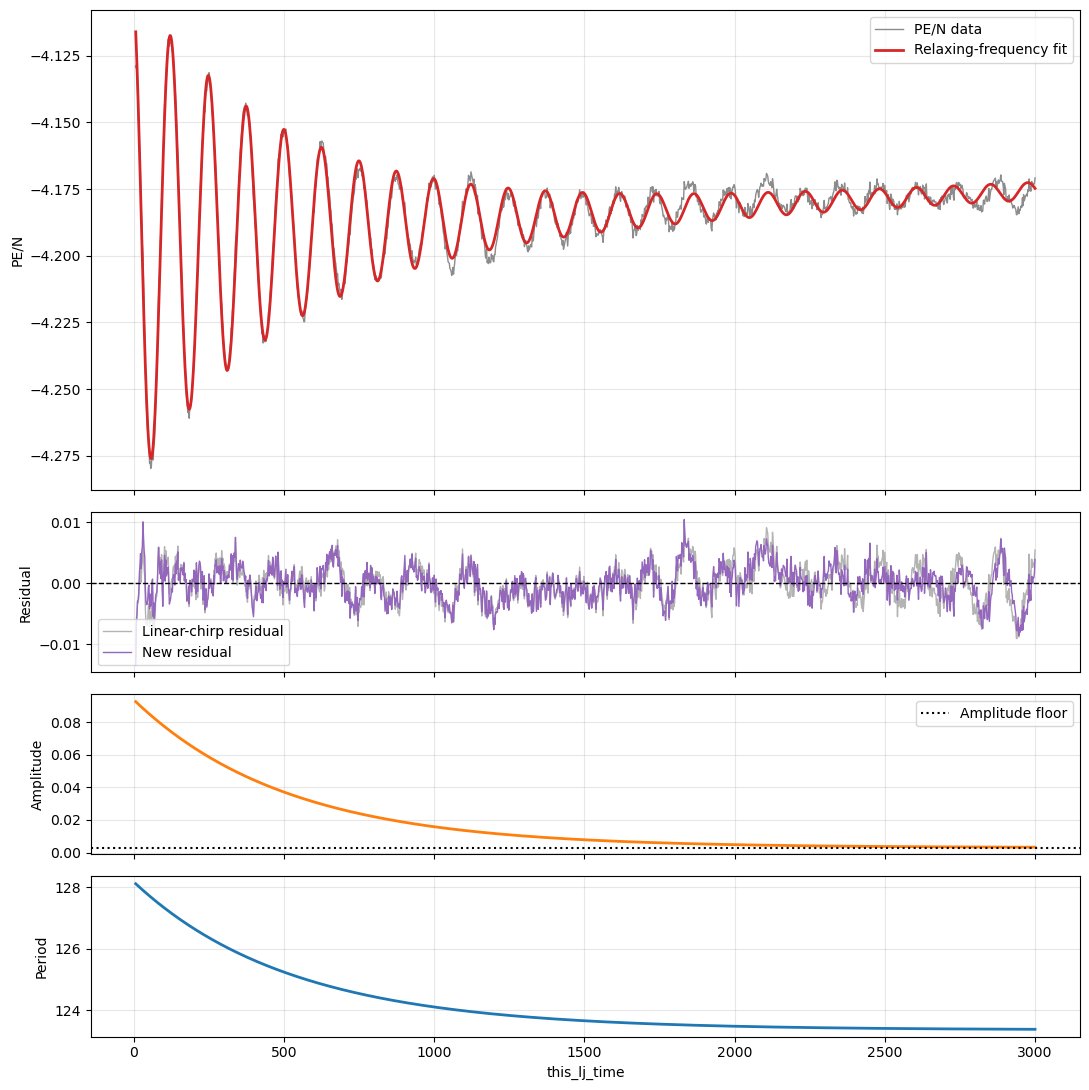

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

def relaxing_frequency_model(
    t,
    C0,
    slope,
    A_floor,
    A_decay,
    tau_amplitude,
    omega_initial,
    omega_final,
    tau_frequency,
    phase,
):
    background = C0 + slope * t

    amplitude = (
        A_floor
        + A_decay * np.exp(-t / tau_amplitude)
    )

    integrated_phase = (
        phase
        + omega_final * t
        + (
            (omega_initial - omega_final)
            * tau_frequency
            * (1.0 - np.exp(-t / tau_frequency))
        )
    )

    return background + amplitude * np.cos(integrated_phase)


# Initial values from the previous chirped fit.
omega_initial0 = omega0_fit
omega_final0 = omega0_fit + alpha_fit * span

# Estimate the persistent late-time amplitude.
late_count = max(20, len(y) // 5)
late_centered = y[-late_count:] - np.mean(y[-late_count:])
A_floor0 = np.sqrt(2.0) * np.std(late_centered)
A_floor0 = np.clip(A_floor0, 1e-5, data_range)

A_decay0 = max(A_fit - A_floor0, 0.01 * data_range)

# For a very long exponential relaxation, D/tau is the measurable slope.
slope0 = D_fit / tau_slow_fit

p0 = np.array([
    C0_fit,
    slope0,
    A_floor0,
    A_decay0,
    tau_amp_fit,
    omega_initial0,
    omega_final0,
    span / 2.0,
    phase_fit,
])

omega_reference = 2.0 * np.pi / 125.0
maximum_slope = 2.0 * data_range / span

lower = np.array([
    y.min() - data_range,       # C0
    -maximum_slope,             # background slope
    0.0,                        # persistent amplitude
    0.0,                        # decaying amplitude
    dt,                         # amplitude decay time
    0.5 * omega_reference,      # initial frequency
    0.5 * omega_reference,      # final frequency
    dt,                         # frequency relaxation time
    -2.0 * np.pi,               # phase
])

upper = np.array([
    y.max() + data_range,
    maximum_slope,
    2.0 * data_range,
    3.0 * data_range,
    100.0 * span,
    2.0 * omega_reference,
    2.0 * omega_reference,
    100.0 * span,
    2.0 * np.pi,
])

relaxing_fit = least_squares(
    lambda parameters: (
        relaxing_frequency_model(t, *parameters) - y
    ),
    x0=np.clip(p0, lower + 1e-12, upper - 1e-12),
    bounds=(lower, upper),
    loss="soft_l1",
    f_scale=noise_scale,
    x_scale="jac",
    max_nfev=300_000,
)

parameter_names = [
    "C0",
    "slope",
    "A_floor",
    "A_decay",
    "tau_amplitude",
    "omega_initial",
    "omega_final",
    "tau_frequency",
    "phase",
]

parameters = dict(zip(parameter_names, relaxing_fit.x))

(
    C0_new,
    slope_new,
    A_floor,
    A_decay,
    tau_amplitude,
    omega_initial,
    omega_final,
    tau_frequency,
    phase_new,
) = relaxing_fit.x

prediction = relaxing_frequency_model(t, *relaxing_fit.x)
new_residual = y - prediction

amplitude_t = (
    A_floor
    + A_decay * np.exp(-t / tau_amplitude)
)

omega_t = (
    omega_final
    + (omega_initial - omega_final)
    * np.exp(-t / tau_frequency)
)
period_t = 2.0 * np.pi / omega_t

# Compare against the linear-chirp model.
rss_chirp = np.sum(chirp_residual**2)
rss_relaxing = np.sum(new_residual**2)

n = len(y)
k_chirp = 8
k_relaxing = 9

aic_chirp = n * np.log(rss_chirp / n) + 2 * k_chirp
aic_relaxing = n * np.log(rss_relaxing / n) + 2 * k_relaxing

bic_chirp = n * np.log(rss_chirp / n) + k_chirp * np.log(n)
bic_relaxing = (
    n * np.log(rss_relaxing / n)
    + k_relaxing * np.log(n)
)

summary = pd.DataFrame({
    "quantity": parameter_names + [
        "initial_period",
        "final_period",
        "delta_AIC_vs_linear_chirp",
        "delta_BIC_vs_linear_chirp",
    ],
    "value": list(relaxing_fit.x) + [
        period_t[0],
        period_t[-1],
        aic_relaxing - aic_chirp,
        bic_relaxing - bic_chirp,
    ],
})
display(summary)

figure, axes = plt.subplots(
    4,
    1,
    figsize=(11, 11),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1, 1]},
)

axes[0].plot(x, y, color="0.55", linewidth=1, label="PE/N data")
axes[0].plot(
    x,
    prediction,
    color="tab:red",
    linewidth=2,
    label="Relaxing-frequency fit",
)
axes[0].set_ylabel("PE/N")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    x,
    chirp_residual,
    color="0.7",
    linewidth=1,
    label="Linear-chirp residual",
)
axes[1].plot(
    x,
    new_residual,
    color="tab:purple",
    linewidth=1,
    label="New residual",
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Residual")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(x, amplitude_t, color="tab:orange", linewidth=2)
axes[2].axhline(
    A_floor,
    color="black",
    linestyle=":",
    label="Amplitude floor",
)
axes[2].set_ylabel("Amplitude")
axes[2].grid(alpha=0.3)
axes[2].legend()

axes[3].plot(x, period_t, color="tab:blue", linewidth=2)
axes[3].set_xlabel("this_lj_time")
axes[3].set_ylabel("Period")
axes[3].grid(alpha=0.3)

figure.tight_layout()
plt.show()

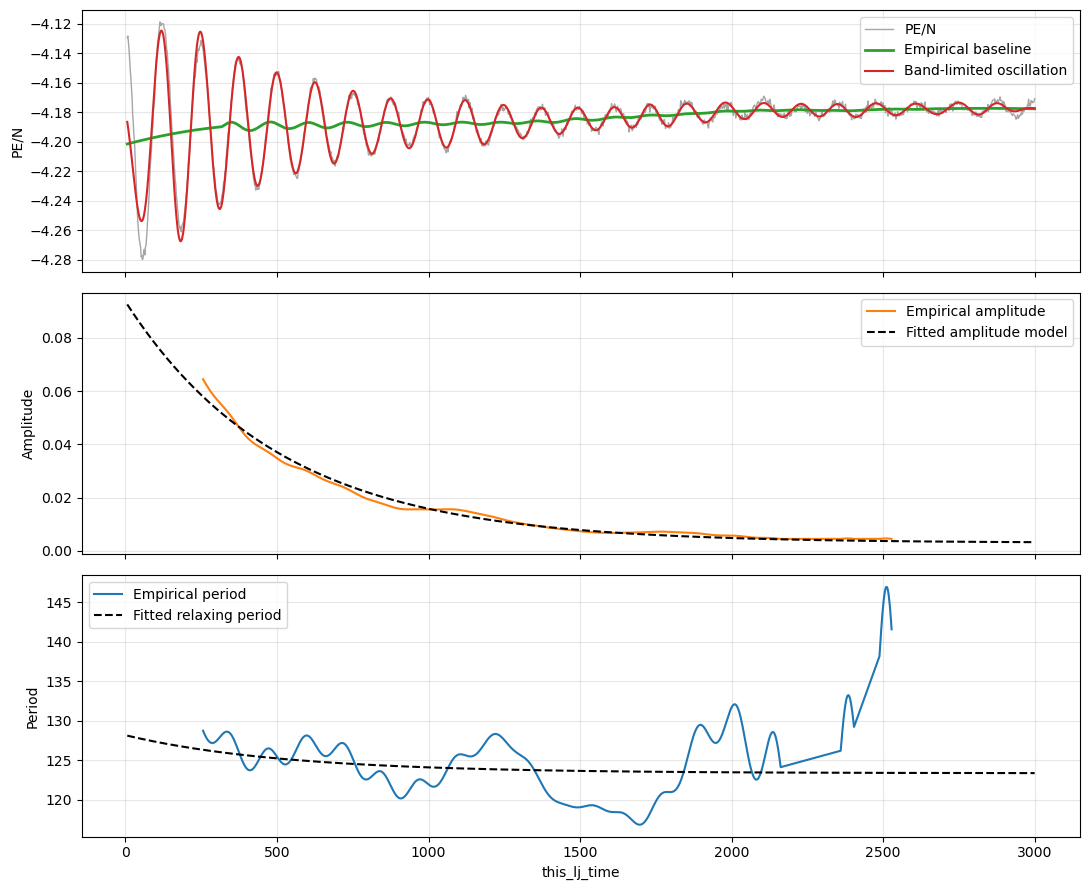

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import (
    butter,
    hilbert,
    savgol_filter,
    sosfiltfilt,
)

sample_dt = np.median(np.diff(t))
nominal_period = 125.0

def valid_odd_window(requested, length, minimum=5):
    window = max(minimum, int(round(requested)))
    if window % 2 == 0:
        window += 1

    maximum = length if length % 2 == 1 else length - 1
    return min(window, maximum)

# Remove changes occurring much more slowly than the oscillation.
baseline_window = valid_odd_window(
    5.0 * nominal_period / sample_dt,
    len(y),
)
empirical_baseline = savgol_filter(
    y,
    window_length=baseline_window,
    polyorder=2,
)

detrended_signal = y - empirical_baseline

# Retain oscillations with periods between roughly 90 and 170.
sos = butter(
    3,
    [1.0 / 170.0, 1.0 / 90.0],
    btype="bandpass",
    fs=1.0 / sample_dt,
    output="sos",
)
filtered_signal = sosfiltfilt(sos, detrended_signal)

analytic_signal = hilbert(filtered_signal)
empirical_phase = np.unwrap(np.angle(analytic_signal))
raw_amplitude = np.abs(analytic_signal)

instantaneous_frequency = (
    np.gradient(empirical_phase, t) / (2.0 * np.pi)
)

smoothing_window = valid_odd_window(
    nominal_period / sample_dt,
    len(y),
)

empirical_amplitude = savgol_filter(
    raw_amplitude,
    smoothing_window,
    polyorder=2,
)

smoothed_frequency = savgol_filter(
    instantaneous_frequency,
    smoothing_window,
    polyorder=2,
)

empirical_period = np.full_like(smoothed_frequency, np.nan)
valid_frequency = smoothed_frequency > 0
empirical_period[valid_frequency] = (
    1.0 / smoothed_frequency[valid_frequency]
)

# Hilbert estimates are unreliable near the boundaries and when amplitude
# becomes very small.
edge_time = 2.0 * nominal_period
reliable = (
    (t >= edge_time)
    & (t <= t[-1] - edge_time)
    & (empirical_amplitude > np.percentile(empirical_amplitude, 20))
)

figure, axes = plt.subplots(
    3,
    1,
    figsize=(11, 9),
    sharex=True,
)

axes[0].plot(x, y, color="0.65", linewidth=1, label="PE/N")
axes[0].plot(
    x,
    empirical_baseline,
    color="tab:green",
    linewidth=2,
    label="Empirical baseline",
)
axes[0].plot(
    x,
    empirical_baseline + filtered_signal,
    color="tab:red",
    linewidth=1.5,
    label="Band-limited oscillation",
)
axes[0].set_ylabel("PE/N")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    x[reliable],
    empirical_amplitude[reliable],
    color="tab:orange",
    label="Empirical amplitude",
)
axes[1].plot(
    x,
    amplitude_t,
    color="black",
    linestyle="--",
    label="Fitted amplitude model",
)
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(
    x[reliable],
    empirical_period[reliable],
    color="tab:blue",
    label="Empirical period",
)
axes[2].plot(
    x,
    period_t,
    color="black",
    linestyle="--",
    label="Fitted relaxing period",
)
axes[2].set_xlabel("this_lj_time")
axes[2].set_ylabel("Period")
axes[2].grid(alpha=0.3)
axes[2].legend()

figure.tight_layout()
plt.show()

,First half,Second half
E_inf,-4.186235,-4.177179
B,-0.007811,-0.007943
tau_drift,495.366436,459.270043
tau_drift/window,0.331127,0.306999
background_start,-4.194046,-4.185122
background_end,-4.186616,-4.177485
background_change,0.007430,0.007637
A_start,0.090180,0.007791
A_end,0.006389,0.002922
tau_amplitude,565.109265,1525.516371


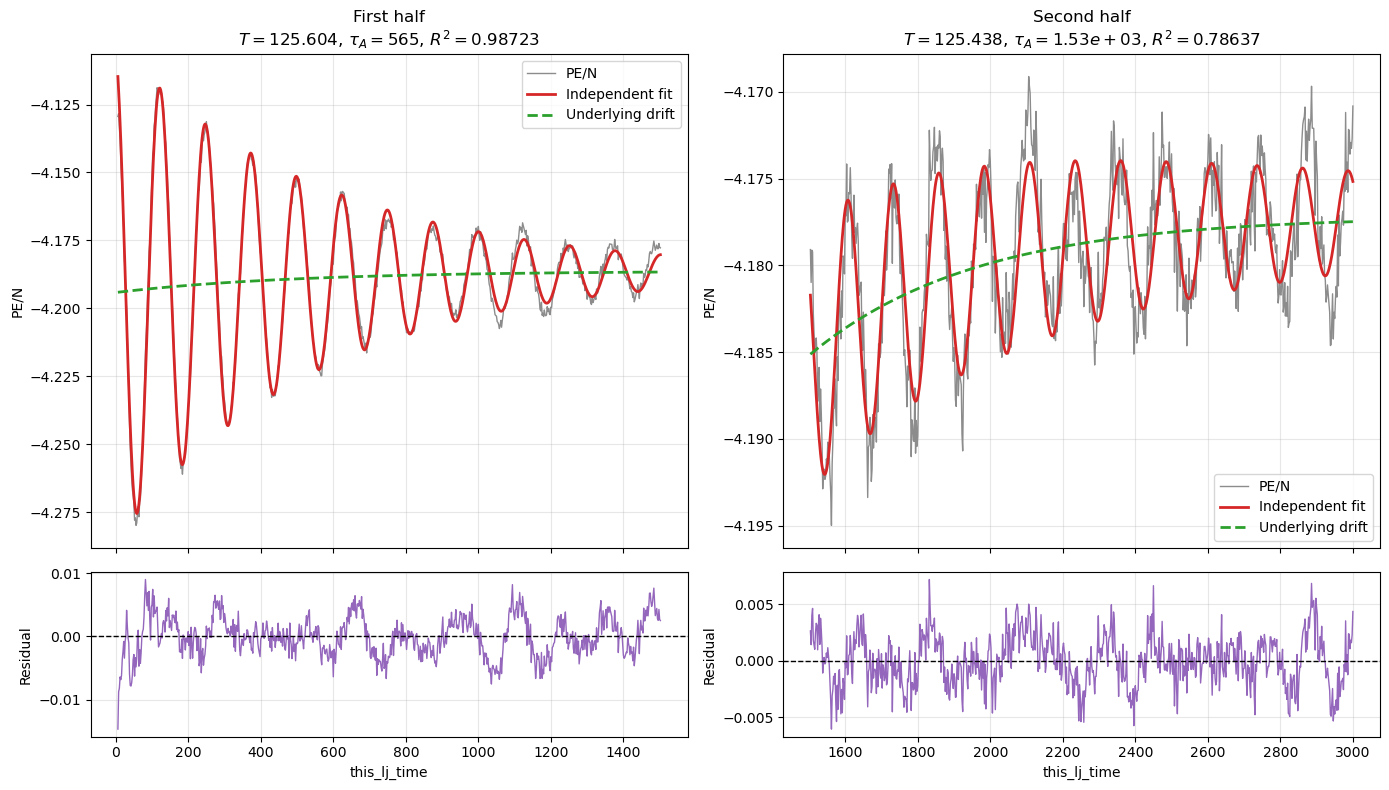

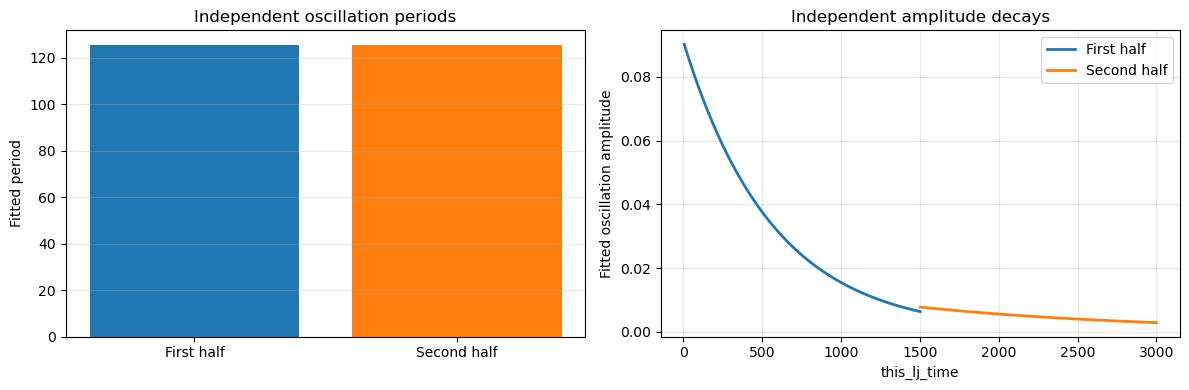

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.signal import detrend

# Load data and omit the first three lattice-transient points.
logs = (
    run.logs_dataframe()
    .sort_values("this_lj_time")
    .reset_index(drop=True)
    .iloc[3:]
)

x_all = logs["this_lj_time"].to_numpy(dtype=float)
y_all = logs["potential_energy_per_particle"].to_numpy(dtype=float)

finite = np.isfinite(x_all) & np.isfinite(y_all)
x_all = x_all[finite]
y_all = y_all[finite]

split_time = 0.5 * (x_all[0] + x_all[-1])

segments = {
    "First half": x_all <= split_time,
    "Second half": x_all > split_time,
}


def half_model(
    u,
    E_inf,
    B,
    tau_drift,
    A,
    tau_amplitude,
    period,
    phase,
):
    background = E_inf + B * np.exp(-u / tau_drift)

    oscillation = (
        A
        * np.exp(-u / tau_amplitude)
        * np.cos(2.0 * np.pi * u / period + phase)
    )

    return background + oscillation


def fit_half(x, y):
    # Reset time within this half.
    u = x - x[0]
    duration = u[-1]
    dt = np.median(np.diff(u))
    y_range = np.ptp(y)

    # FFT estimate of the oscillation period.
    frequencies = np.fft.rfftfreq(len(u), d=dt)
    spectrum = np.abs(np.fft.rfft(detrend(y)))

    valid_frequency = (
        (frequencies > 1.0 / duration)
        & (frequencies < 0.5 / dt)
    )

    peak_index = np.flatnonzero(valid_frequency)[
        np.argmax(spectrum[valid_frequency])
    ]
    frequency0 = frequencies[peak_index]
    period0 = 1.0 / frequency0

    tail_count = max(10, len(y) // 5)
    early_count = max(5, len(y) // 10)

    E_inf0 = np.median(y[-tail_count:])
    B0 = np.mean(y[:early_count]) - E_inf0

    approximately_detrended = detrend(y)
    complex_amplitude = np.sum(
        approximately_detrended
        * np.exp(-2j * np.pi * frequency0 * u)
    )
    phase0 = np.angle(complex_amplitude)

    A0 = max(
        np.max(np.abs(approximately_detrended[:early_count])),
        0.25 * y_range,
    )

    base_initial = np.array([
        E_inf0,
        B0,
        max(duration, dt),
        A0,
        max(duration / 3.0, dt),
        period0,
        phase0,
    ])

    period_lower = max(2.1 * dt, period0 / 2.0)
    period_upper = min(duration, 2.0 * period0)

    lower = np.array([
        y.min() - y_range,
        -2.0 * y_range,
        dt,
        0.0,
        dt,
        period_lower,
        -4.0 * np.pi,
    ])

    upper = np.array([
        y.max() + y_range,
        2.0 * y_range,
        100.0 * duration,
        3.0 * y_range,
        100.0 * duration,
        period_upper,
        4.0 * np.pi,
    ])

    tail = y[-tail_count:]
    noise_scale = 1.4826 * np.median(
        np.abs(tail - np.median(tail))
    )
    noise_scale = max(noise_scale, 1e-6)

    # Multiple phase starts reduce the chance of selecting a local minimum.
    candidate_fits = []

    for phase_offset in np.linspace(-np.pi, np.pi, 9):
        initial = base_initial.copy()
        initial[-1] += phase_offset
        initial = np.clip(initial, lower + 1e-12, upper - 1e-12)

        candidate = least_squares(
            lambda parameters: half_model(u, *parameters) - y,
            x0=initial,
            bounds=(lower, upper),
            loss="soft_l1",
            f_scale=noise_scale,
            x_scale="jac",
            max_nfev=200_000,
        )
        candidate_fits.append(candidate)

    result = min(
        candidate_fits,
        key=lambda candidate: np.sum(
            (half_model(u, *candidate.x) - y) ** 2
        ),
    )

    prediction = half_model(u, *result.x)
    residual = y - prediction

    (
        E_inf,
        B,
        tau_drift,
        A,
        tau_amplitude,
        period,
        phase,
    ) = result.x

    background = E_inf + B * np.exp(-u / tau_drift)
    amplitude = A * np.exp(-u / tau_amplitude)

    rss = np.sum(residual**2)
    r_squared = 1.0 - rss / np.sum((y - np.mean(y)) ** 2)

    summary = {
        "E_inf": E_inf,
        "B": B,
        "tau_drift": tau_drift,
        "tau_drift/window": tau_drift / duration,
        "background_start": background[0],
        "background_end": background[-1],
        "background_change": background[-1] - background[0],
        "A_start": amplitude[0],
        "A_end": amplitude[-1],
        "tau_amplitude": tau_amplitude,
        "tau_amplitude/window": tau_amplitude / duration,
        "period": period,
        "phase": phase,
        "R_squared": r_squared,
        "RMSE": np.sqrt(np.mean(residual**2)),
    }

    return {
        "x": x,
        "u": u,
        "y": y,
        "prediction": prediction,
        "background": background,
        "amplitude": amplitude,
        "residual": residual,
        "parameters": result.x,
        "summary": summary,
    }


fits = {
    name: fit_half(x_all[mask], y_all[mask])
    for name, mask in segments.items()
}

comparison = pd.DataFrame({
    name: result["summary"]
    for name, result in fits.items()
})
display(comparison)


# Plot each completely independent fit and its residual.
figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
    sharex="col",
    gridspec_kw={"height_ratios": [3, 1]},
)

for column, (name, result) in enumerate(fits.items()):
    x = result["x"]
    y = result["y"]

    axes[0, column].plot(
        x,
        y,
        color="0.55",
        linewidth=1,
        label="PE/N",
    )
    axes[0, column].plot(
        x,
        result["prediction"],
        color="tab:red",
        linewidth=2,
        label="Independent fit",
    )
    axes[0, column].plot(
        x,
        result["background"],
        color="tab:green",
        linestyle="--",
        linewidth=2,
        label="Underlying drift",
    )

    summary = result["summary"]
    axes[0, column].set_title(
        f"{name}\n"
        rf"$T={summary['period']:.3f}$, "
        rf"$\tau_A={summary['tau_amplitude']:.3g}$, "
        rf"$R^2={summary['R_squared']:.5f}$"
    )
    axes[0, column].set_ylabel("PE/N")
    axes[0, column].grid(alpha=0.3)
    axes[0, column].legend()

    axes[1, column].plot(
        x,
        result["residual"],
        color="tab:purple",
        linewidth=1,
    )
    axes[1, column].axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )
    axes[1, column].set_xlabel("this_lj_time")
    axes[1, column].set_ylabel("Residual")
    axes[1, column].grid(alpha=0.3)

figure.tight_layout()
plt.show()


# Directly compare fitted periods and amplitude envelopes.
figure, (period_axis, amplitude_axis) = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

names = list(fits)
periods = [fits[name]["summary"]["period"] for name in names]

period_axis.bar(names, periods, color=["tab:blue", "tab:orange"])
period_axis.set_ylabel("Fitted period")
period_axis.set_title("Independent oscillation periods")
period_axis.grid(axis="y", alpha=0.3)

for name, result in fits.items():
    amplitude_axis.plot(
        result["x"],
        result["amplitude"],
        linewidth=2,
        label=name,
    )

amplitude_axis.set_xlabel("this_lj_time")
amplitude_axis.set_ylabel("Fitted oscillation amplitude")
amplitude_axis.set_title("Independent amplitude decays")
amplitude_axis.grid(alpha=0.3)
amplitude_axis.legend()

figure.tight_layout()
plt.show()

In [12]:
# Estimate the late residual noise level.
late_count = max(50, len(new_residual) // 5)
residual_noise = np.std(new_residual[-late_count:])

# A sinusoidal signal should have amplitude comfortably above the
# pointwise residual noise before its phase derivative is trusted.
amplitude_threshold = max(
    3.0 * residual_noise,
    0.10 * np.max(empirical_amplitude),
)

edge_time = 2.0 * nominal_period

high_snr = (
    (t >= edge_time)
    & (t <= t[-1] - edge_time)
    & (empirical_amplitude >= amplitude_threshold)
    & np.isfinite(empirical_period)
)

print(f"Residual noise estimate: {residual_noise:.6g}")
print(f"Amplitude threshold:     {amplitude_threshold:.6g}")
print(
    "Reliable period interval:",
    f"{x[high_snr][0]:.1f} to {x[high_snr][-1]:.1f}",
)

figure, (amplitude_axis, period_axis) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)

amplitude_axis.plot(
    x,
    empirical_amplitude,
    color="0.75",
    label="Empirical amplitude",
)
amplitude_axis.plot(
    x[high_snr],
    empirical_amplitude[high_snr],
    color="tab:orange",
    linewidth=2,
    label="Reliable-amplitude region",
)
amplitude_axis.plot(
    x,
    amplitude_t,
    color="black",
    linestyle="--",
    label="Fitted amplitude",
)
amplitude_axis.axhline(
    amplitude_threshold,
    color="tab:red",
    linestyle=":",
    label="SNR threshold",
)
amplitude_axis.set_ylabel("Amplitude")
amplitude_axis.grid(alpha=0.3)
amplitude_axis.legend()

period_axis.plot(
    x,
    empirical_period,
    color="0.8",
    label="Low- and high-SNR estimate",
)
period_axis.plot(
    x[high_snr],
    empirical_period[high_snr],
    color="tab:blue",
    linewidth=2,
    label="Reliable empirical period",
)
period_axis.plot(
    x,
    period_t,
    color="black",
    linestyle="--",
    label="Fitted relaxing period",
)
period_axis.set_xlabel("this_lj_time")
period_axis.set_ylabel("Period")
period_axis.grid(alpha=0.3)
period_axis.legend()

figure.tight_layout()
plt.show()

Residual noise estimate: 0.00287454
Amplitude threshold:     0.00862362


IndexError: boolean index did not match indexed array along axis 0; size of axis is 749 but size of corresponding boolean axis is 1498

In [13]:
first = fits["First half"]
second = fits["Second half"]

p_first = first["parameters"]
p_second = second["parameters"]

period_first = p_first[5]
phase_first = p_first[6]
phase_second = p_second[6]

# Advance the first-half phase to the first time in the second half.
elapsed_to_second = second["x"][0] - first["x"][0]

expected_second_phase = (
    phase_first
    + 2.0 * np.pi * elapsed_to_second / period_first
)

# Signed phase difference in [-pi, pi].
phase_jump = np.angle(
    np.exp(1j * (phase_second - expected_second_phase))
)

time_offset = phase_jump * period_first / (2.0 * np.pi)

print(f"Phase mismatch at split: {phase_jump:.5f} radians")
print(f"Equivalent timing offset: {time_offset:.5f} LJ time units")

Phase mismatch at split: 1.08578 radians
Equivalent timing offset: 21.70522 LJ time units
